## Final Project

**Part 1: Preprocessing**
- Removed null values
- Normalized specific columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SKLogReg
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error
from scipy.sparse.linalg import svds
import statsmodels.api as sm

In [2]:
#Load data
df = pd.read_csv('customer_support_tickets_200k.csv')
print(f"Shape : {df.shape}\n")
print(df.info())

Shape : (200000, 30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 

In [16]:
print("Initial glance at data...\n")
display(df.head())

Initial glance at data...



,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [17]:
print(df['browser'].isna().sum())

40023


In [9]:
#browser: 40,023 nulls (~20%)
#Investigate whether missingness is random or systematic
print('browser nulls by channel:')
display(
    df.groupby('channel')['browser']
      .apply(lambda x: x.isna().mean().round(3))
      .rename('pct_missing')
      .sort_values(ascending=False)
)

print('\nbrowser nulls by operating_system:')
display(
    df.groupby('operating_system')['browser']
      .apply(lambda x: x.isna().mean().round(3))
      .rename('pct_missing')
      .sort_values(ascending=False)
)

print("\nThe nulls are evenly spread across channels and OS, so the missingness isn't explained by any structural grouping " +
      "(e.g. 'phone calls don't have a browser'). Therefore, since the browser column isn't central to our research question," +
      "we choose to drop it. 20% missing with no clear pattern is a data quality issue, and any imputation is just inventing data in this situation.")

browser nulls by channel:


channel
Social Media    0.203
Phone           0.202
Chat            0.200
Web Form        0.199
Email           0.197
Name: pct_missing, dtype: float64


browser nulls by operating_system:


operating_system
Linux      0.202
Windows    0.202
MacOS      0.200
iOS        0.199
Android    0.198
Name: pct_missing, dtype: float64


The nulls are evenly spread across channels and OS, so the missingness isn't explained by any structural grouping (e.g. 'phone calls don't have a browser'). Therefore, since the browser column isn't central to our research question,we choose to drop it. 20% missing with no clear pattern is a data quality issue, and any imputation is just inventing data in this situation.


In [18]:
#Numerical summary

print("Numerical columns: No large outliers to handle\n")
df.describe().round(2)

Numerical columns: No large outliers to handle



,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,100000.50,46.47,30.38,9.99,3.00,36.31,120.54,5.50
std,57735.17,16.75,17.33,6.05,1.41,20.65,68.97,2.88
min,1.00,18.00,1.00,0.00,1.00,0.50,1.00,1.00
25%,50000.75,32.00,15.00,5.00,2.00,18.46,60.81,3.00
50%,100000.50,46.00,30.00,10.00,3.00,36.31,120.45,6.00
75%,150000.25,61.00,45.00,15.00,4.00,54.22,180.26,8.00
max,200000.00,75.00,60.00,20.00,5.00,72.00,240.00,10.00


In [10]:
# IQR-based outlier detection for numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'column': col, 'lower_fence': round(lower,2),
                            'upper_fence': round(upper,2), 'outlier_count': n_out,
                            'outlier_pct': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_count', ascending=False)
display(outlier_df)

,column,lower_fence,upper_fence,outlier_count,outlier_pct
0,ticket_id,-99998.50,299999.50,0,0.0
1,customer_age,-11.50,104.50,0,0.0
2,customer_tenure_months,-30.00,90.00,0,0.0
3,previous_tickets,-10.00,30.00,0,0.0
4,customer_satisfaction_score,-1.00,7.00,0,0.0
5,first_response_time_hours,-35.18,107.86,0,0.0
6,resolution_time_hours,-118.36,359.43,0,0.0
7,issue_complexity_score,-4.50,15.50,0,0.0


In [19]:
#Categorical summary

obj_cols = df.select_dtypes('object').columns
categorical_summary = pd.DataFrame({
    'unique_values': df[obj_cols].nunique(),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in obj_cols]
})

print("Categorical columns: Must convert 4 object columns (2 Date-time, 2 Boolean).\n")
display(categorical_summary)

Categorical columns: Must convert 4 object columns (2 Date-time, 2 Boolean).



,unique_values,sample_values
customer_name,400,"[Patricia Smith, Patricia Williams, William An..."
customer_email,191751,"[patricia.smith760@outlook.com, patricia.willi..."
product,10,"[Web Portal, Mobile App, Payment Gateway, Subs..."
category,10,"[Account Suspension, Performance Issue, Subscr..."
issue_description,10,[The payment was deducted from my bank account...
resolution_notes,10,[Data synchronization restored after backend s...
priority,4,"[Urgent, Medium, High, Low]"
status,5,"[Open, Closed, Pending Customer, In Progress, ..."
channel,5,"[Email, Chat, Social Media, Phone, Web Form]"
region,6,"[North America, South America, Europe, Asia, A..."


In [3]:
#Date-time columns: convert from object
date_cols = ['ticket_created_date', 'ticket_resolved_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    n_failed = df[col].isna().sum()
    print(f'{col} : converted to datetime : {n_failed} unparseable values (NaT)')

# Boolean-like columns: convert from object
bool_map = {'Yes': True, 'No': False}
for col in ['escalated', 'sla_breached']:
    df[col] = df[col].map(bool_map)
    print(f'{col} : converted to bool. NAs introduced: {df[col].isna().sum()}')

ticket_created_date : converted to datetime : 0 unparseable values (NaT)
ticket_resolved_date : converted to datetime : 0 unparseable values (NaT)
escalated : converted to bool. NAs introduced: 0
sla_breached : converted to bool. NAs introduced: 0


No string columns with embedded units (e.g. $, #, GB, %).  
No trailing whitespace or hidden characters.  
No inconsistent formatting or casing for categorical columns.  
No inconsistent units in numerical columns.  
No duplicate rows or duplicate ticket IDs.  
No invalid (negative) value counts.

**Part 2: Data Visualization**

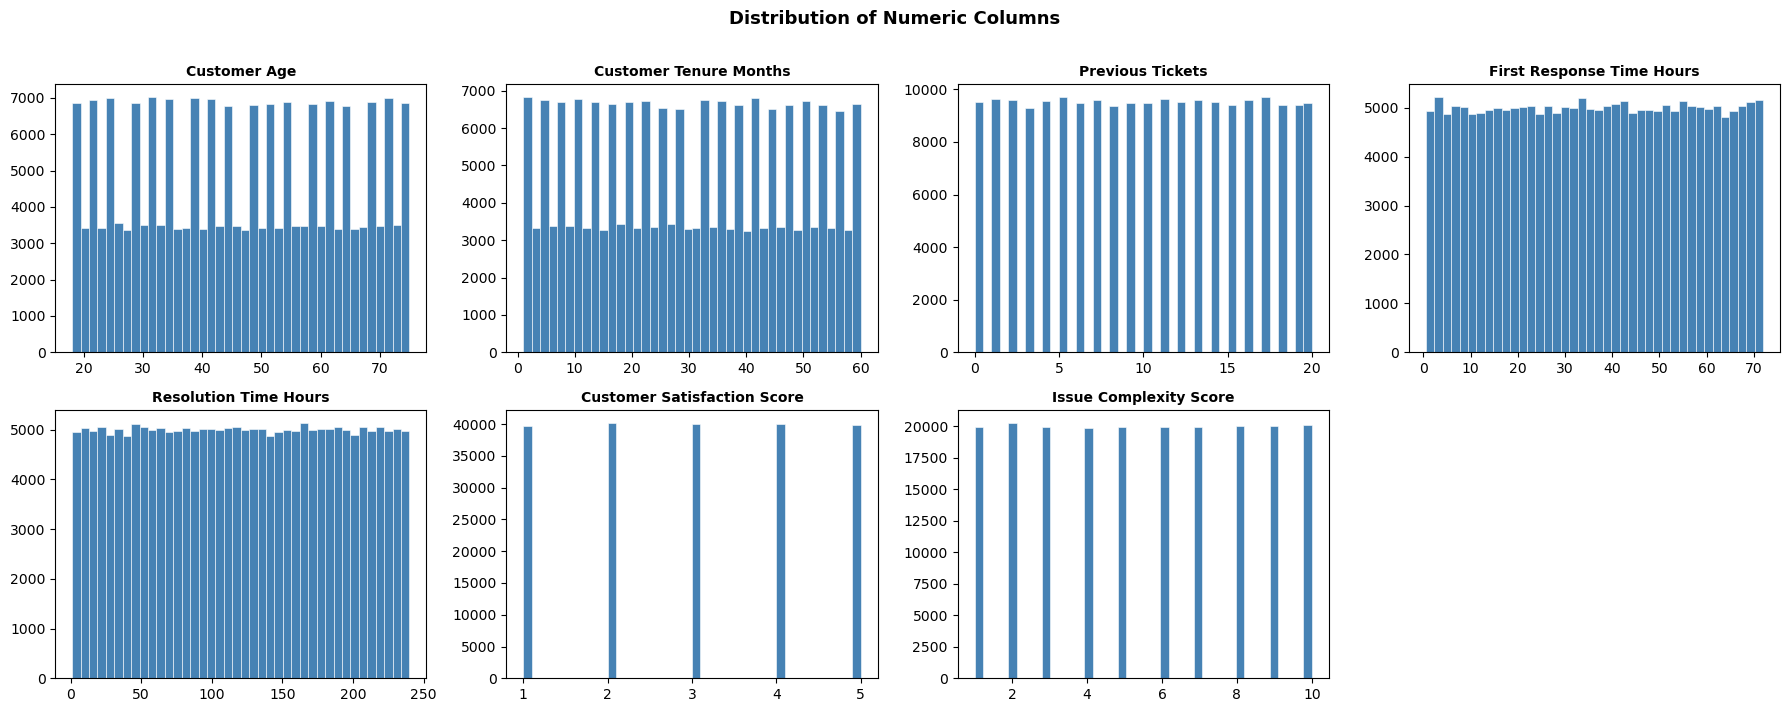

In [13]:
#Numeric column distributions
key_num = ['customer_age', 'customer_tenure_months', 'previous_tickets',
           'first_response_time_hours', 'resolution_time_hours',
           'customer_satisfaction_score', 'issue_complexity_score']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(key_num):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
        axes[i].set_xlabel('')

for j in range(len(key_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

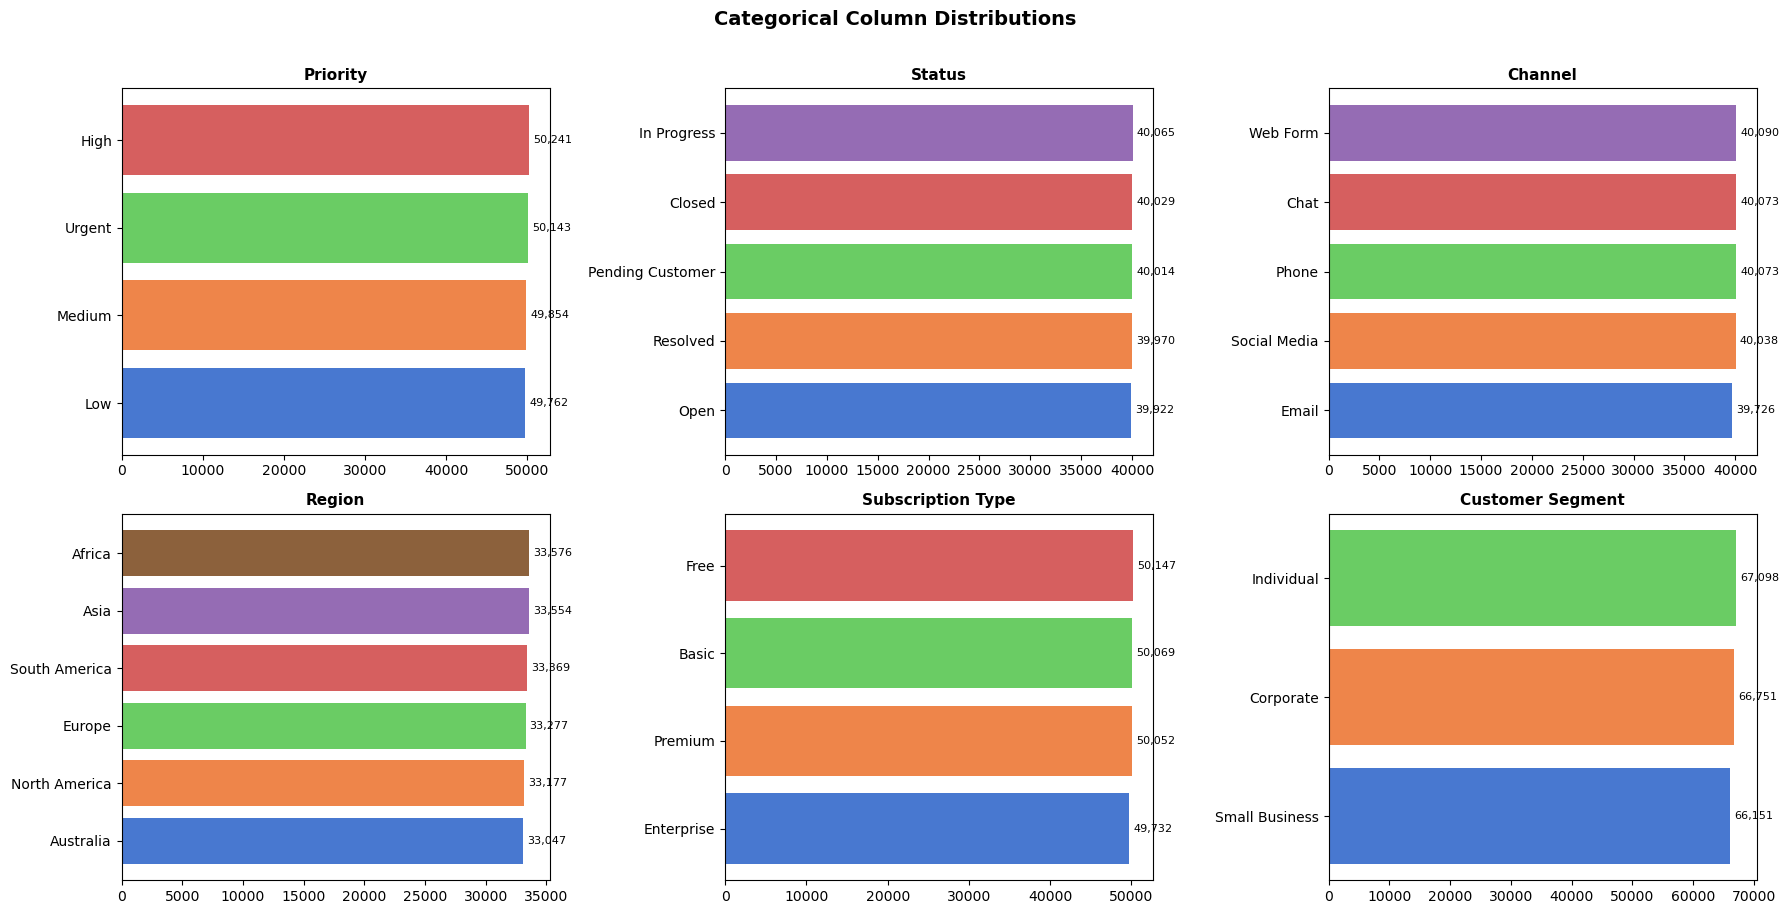

In [14]:
#Categorical columns visualization
cat_cols_viz = ['priority', 'status', 'channel', 'region',
                'subscription_type', 'customer_segment']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols_viz):
    counts = df[col].value_counts()
    axes[i].barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold', fontsize=11)
    for bar, val in zip(axes[i].patches, counts.values[::-1]):
        axes[i].text(bar.get_width() + counts.values.max()*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)

plt.suptitle('Categorical Column Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

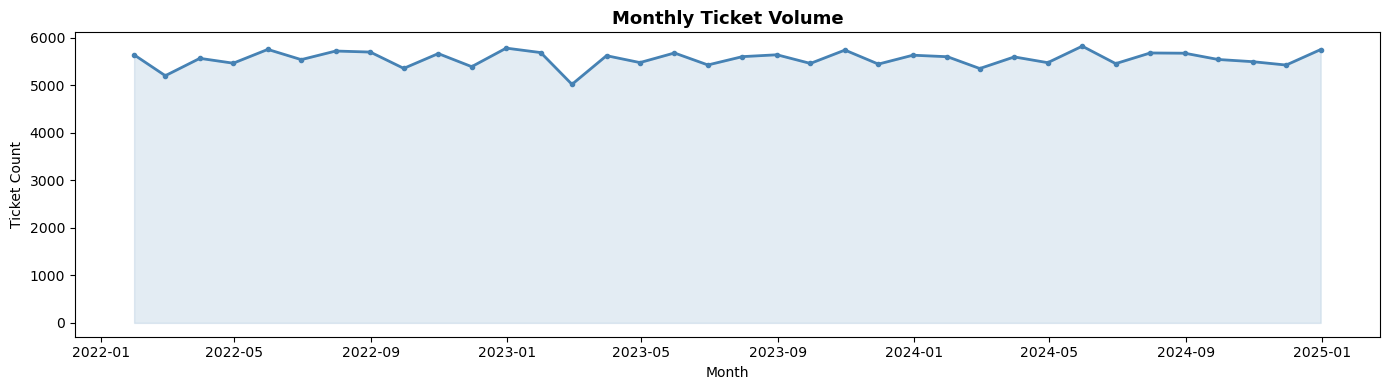

In [15]:
#Ticket volume over time
tickets_over_time = df.set_index('ticket_created_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(tickets_over_time.index, tickets_over_time.values,
        color='steelblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(tickets_over_time.index, tickets_over_time.values, alpha=0.15, color='steelblue')
ax.set_title('Monthly Ticket Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Ticket Count')
plt.tight_layout()
plt.show()

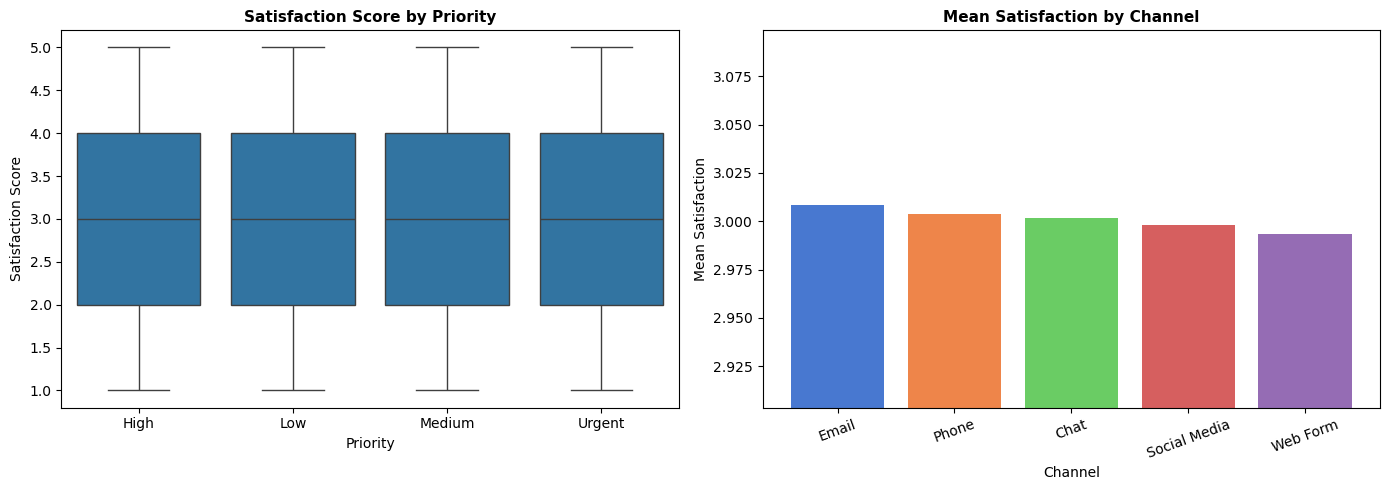

In [17]:
#Customer satisfaction by priority and channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: satisfaction by priority
priority_order = df.groupby('priority')['customer_satisfaction_score'].median().sort_values().index.tolist()
sns.boxplot(data=df, x='priority', y='customer_satisfaction_score',
            order=priority_order, ax=axes[0])
axes[0].set_title('Satisfaction Score by Priority', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Satisfaction Score')

# Mean satisfaction by channel
chan_sat = df.groupby('channel')['customer_satisfaction_score'].mean().sort_values(ascending=False)
axes[1].bar(chan_sat.index, chan_sat.values, color=sns.color_palette('muted', len(chan_sat)))
axes[1].set_title('Mean Satisfaction by Channel', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Mean Satisfaction')
axes[1].set_ylim(chan_sat.min() * 0.97, chan_sat.max() * 1.03)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

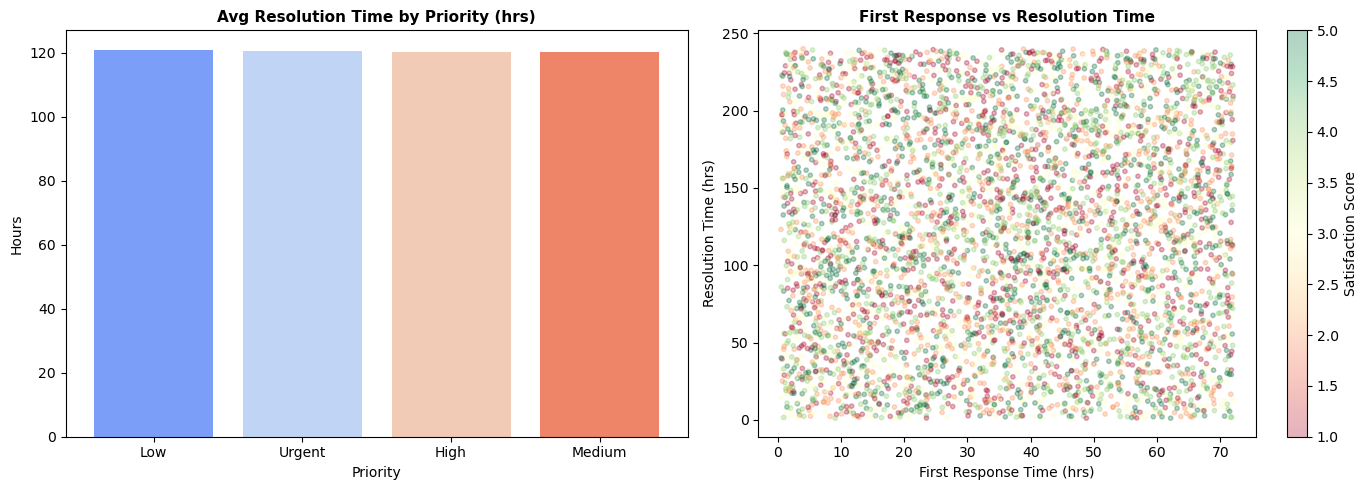

In [18]:
#Response and resolution: Time analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean resolution time by priority
res_priority = df.groupby('priority')['resolution_time_hours'].mean().sort_values(ascending=False)
axes[0].bar(res_priority.index, res_priority.values, color=sns.color_palette('coolwarm', len(res_priority)))
axes[0].set_title('Avg Resolution Time by Priority (hrs)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Hours')

# Scatter: first response vs resolution time (sample for readability)
sample = df.sample(min(5000, len(df)), random_state=42)
sc = axes[1].scatter(sample['first_response_time_hours'], sample['resolution_time_hours'],
                     c=sample['customer_satisfaction_score'], cmap='RdYlGn',
                     alpha=0.3, s=10, vmin=1, vmax=5)
plt.colorbar(sc, ax=axes[1], label='Satisfaction Score')
axes[1].set_title('First Response vs Resolution Time', fontweight='bold', fontsize=11)
axes[1].set_xlabel('First Response Time (hrs)')
axes[1].set_ylabel('Resolution Time (hrs)')

plt.tight_layout()
plt.show()

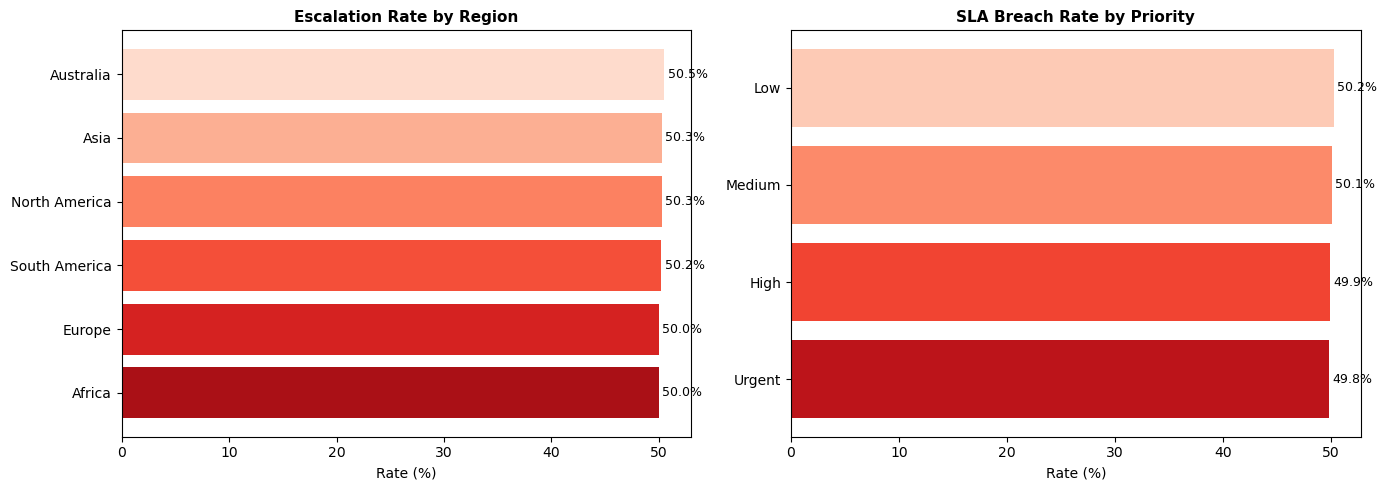

In [19]:
#Escalation and SLA breach rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['escalated', 'sla_breached'],
                           ['Escalation Rate by Region', 'SLA Breach Rate by Priority']):
    grouper = 'region' if col == 'escalated' else 'priority'
    rates = df.groupby(grouper)[col].mean().sort_values(ascending=False)
    ax.barh(rates.index[::-1], (rates.values * 100)[::-1],
            color=sns.color_palette('Reds_r', len(rates)))
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Rate (%)')
    for bar, val in zip(ax.patches, (rates.values * 100)[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

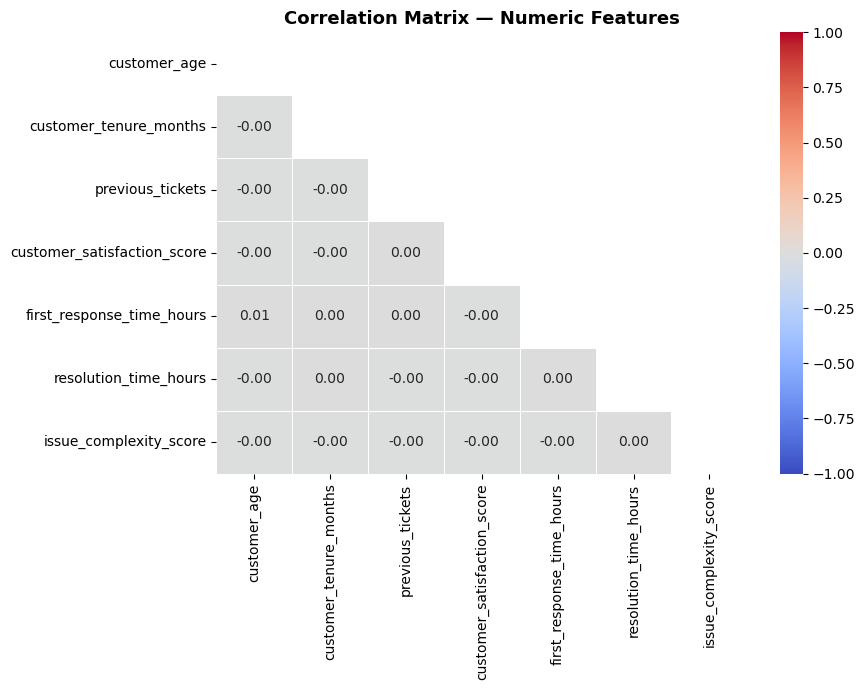

In [20]:
#Correlation heat map: Numerical columns
corr_cols = ['customer_age', 'customer_tenure_months', 'previous_tickets',
             'customer_satisfaction_score', 'first_response_time_hours',
             'resolution_time_hours', 'issue_complexity_score']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

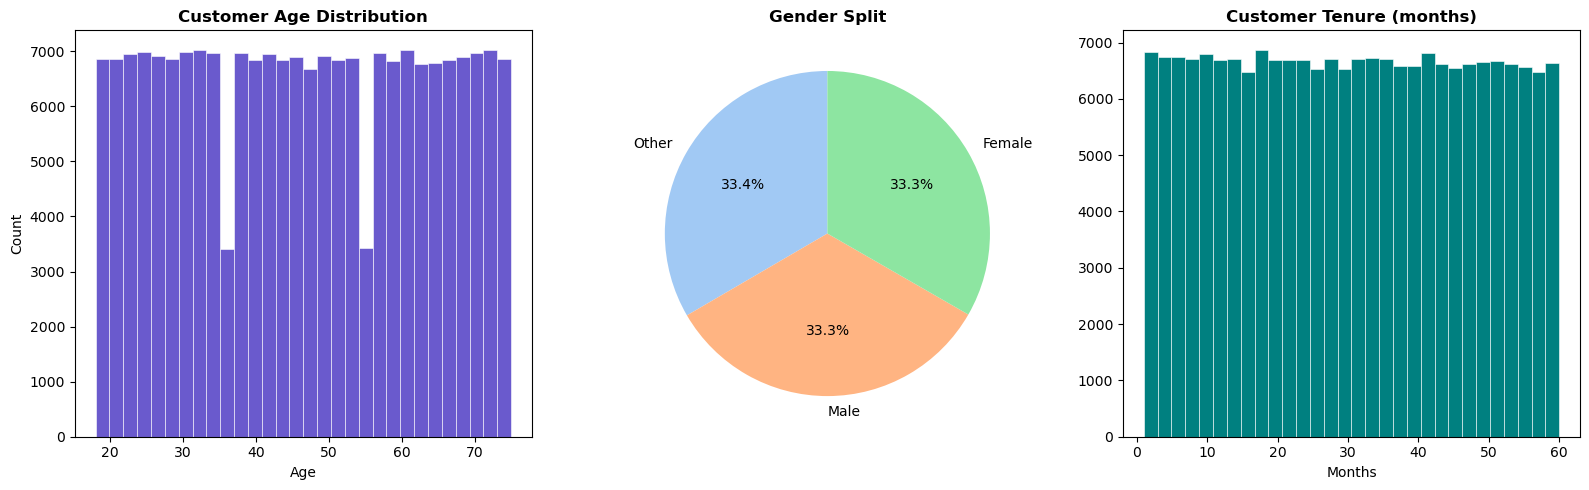

In [21]:
#Customer demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(df['customer_age'], bins=30, color='slateblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Customer Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Gender split
gender_counts = df['customer_gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90)
axes[1].set_title('Gender Split', fontweight='bold')

# Tenure distribution
axes[2].hist(df['customer_tenure_months'], bins=30, color='teal', edgecolor='white', linewidth=0.4)
axes[2].set_title('Customer Tenure (months)', fontweight='bold')
axes[2].set_xlabel('Months')

plt.tight_layout()
plt.show()